# **AI Bootcamp – Week 9 | Day 2 Lab**

# Image Generation Workflows

## Objectives

In this lab, you will explore advanced image generation workflows using Stable Diffusion. Unlike Day 1, where images were generated only from text prompts, today you will learn how to transform existing images, edit specific regions, guide image generation using structural information, and explore text-to-video generation.

By the end of this lab, you will be able to:

- Generate images using Image-to-Image (img2img)
- Understand how the Strength parameter affects generated images
- Edit images using Inpainting
- Guide image generation with ControlNet
- Explore text-to-video generation
- Improve prompts through systematic experimentation

# Step 1 – Enable GPU

Stable Diffusion models require GPU acceleration for efficient execution.

Before continuing:

1. Click **Runtime**
2. Select **Change runtime type**
3. Choose **T4 GPU**
4. Click **Save**

Run the following code to verify that your GPU is available.

In [1]:
import torch

if torch.cuda.is_available():
    print("GPU Available")
    print(torch.cuda.get_device_name(0))
else:
    print("GPU NOT Available")

GPU Available
Tesla T4


# Step 2 – Install Required Libraries

Today's lab requires several additional libraries.

Run the following cell.



In [2]:
!pip -q install diffusers transformers accelerate safetensors opencv-python-headless

# Step 3 – Import Libraries


Complete the missing imports below.

Hint:

You will need

- torch
- numpy
- PIL
- matplotlib
- load_image
- export_to_video

In [3]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers.utils import load_image, export_to_video

# Image-to-Image (img2img)

Unlike Day 1, today's generation starts with an existing image.

Instead of creating a completely new image, Stable Diffusion modifies the original while preserving some of its structure.

The amount of change is controlled by the **Strength** parameter.
# Load the Image-to-Image Pipeline


Complete the missing code.

Model name:

runwayml/stable-diffusion-v1-5

In [4]:
from diffusers import StableDiffusionImg2ImgPipeline

pipe_img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None
)

pipe_img2img = pipe_img2img.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


# Load the Sample Image

Run the following cell to download the sample image.

Feel free to swap in your own by uploading it to Colab and loading it with Image.open().

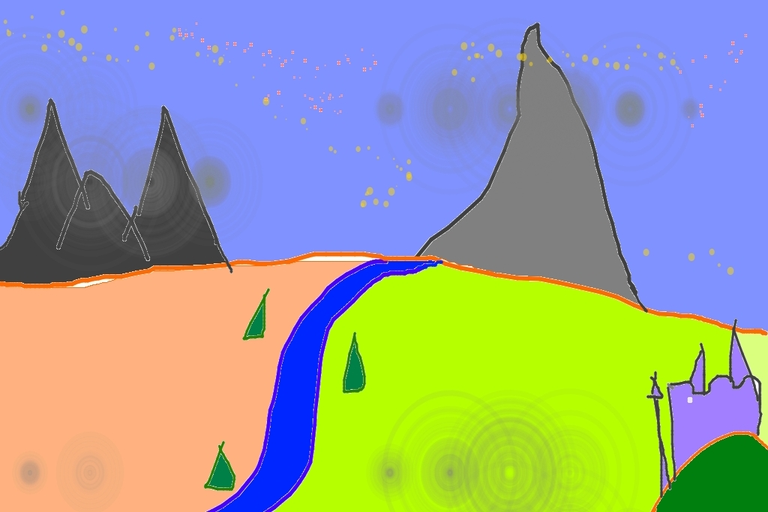

In [5]:
url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
init_image = load_image(url).resize((768, 512))
init_image

 Experiment with the Strength Parameter

The **Strength** parameter determines how much the original image is modified.

Lower values preserve more of the original image.

Higher values generate a more dramatically changed image.


Generate the image using:

- Strength = 0.3
- Strength = 0.6
- Strength = 0.9

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

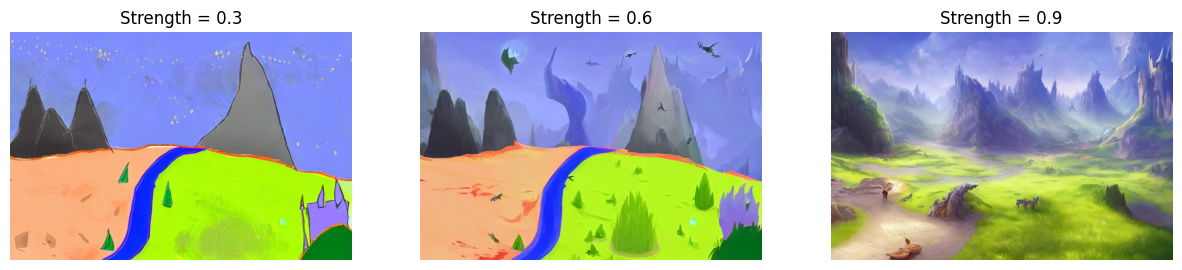

In [6]:
#write your code here
prompt = "a fantasy landscape, trending on artstation"

strengths = [0.3, 0.6, 0.9]
results = []

for s in strengths:
    generator = torch.Generator("cuda").manual_seed(42)
    image = pipe_img2img(
        prompt=prompt,
        image=init_image,
        strength=s,
        guidance_scale=7.5,
        generator=generator
    ).images[0]
    results.append(image)

fig, axes = plt.subplots(1, len(strengths), figsize=(15, 5))
for ax, img, s in zip(axes, results, strengths):
    ax.imshow(img)
    ax.set_title(f"Strength = {s}")
    ax.axis("off")
plt.show()

## Reflection

1. Which strength preserved the original image best?

2. Which strength produced the largest transformation?

3. Which value would you choose if the client wanted only small edits?

In [ ]:
#answer here

1. Strength = 0.3 preserves the original image best — the model only lightly perturbs the latent, so the mountain sketch's composition and layout stay close to the input.
2. Strength = 0.9 produces the largest transformation — at high strength, most of the original latent information is overwritten by the diffusion process, so the output looks much closer to a fresh generation guided loosely by the input's rough shape.
3. For a client who wants only small edits, use a low strength value (around 0.2–0.3). This keeps composition, colors, and structure close to the original while still letting the prompt nudge details like lighting or texture.

#  Inpainting

Instead of changing the whole image, Inpainting edits only the masked region.

The white region of the mask is regenerated.

The black region remains unchanged.

Load the Inpainting Pipeline


Complete the code below.

In [7]:
from diffusers import StableDiffusionInpaintPipeline

pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16,
    safety_checker=None
)

pipe_inpaint = pipe_inpaint.to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing net

Load an image and its mask.

The mask is white where you want new content generated, and black where the original should stay untouched.

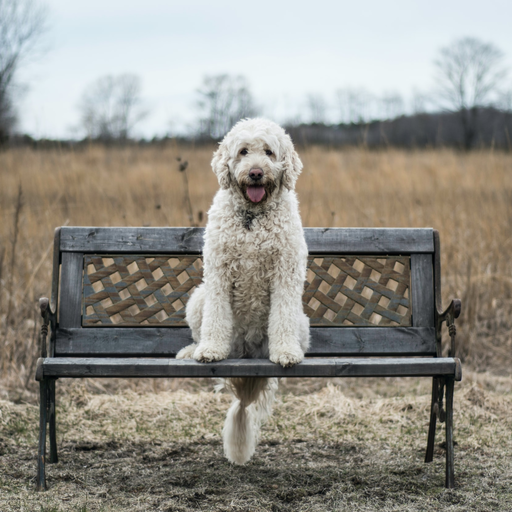

In [8]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = load_image(img_url).resize((512, 512))
mask_image = load_image(mask_url).resize((512, 512))

init_image

 Regenerate the masked region.

 **prompt =** "a majestic tiger sitting on a bench"

  0%|          | 0/50 [00:00<?, ?it/s]

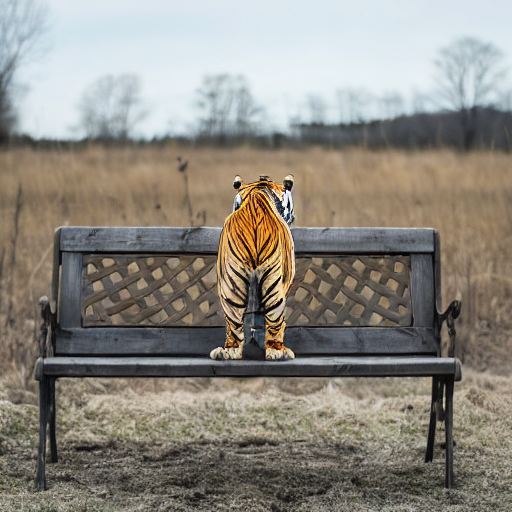

In [19]:
#write your code here
prompt = "a majestic tiger sitting on a bench"

generator = torch.Generator("cuda").manual_seed(42)

result = pipe_inpaint(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image,
    guidance_scale=7.5,
    num_inference_steps=50,
    generator=generator
).images[0]

result

  0%|          | 0/75 [00:00<?, ?it/s]

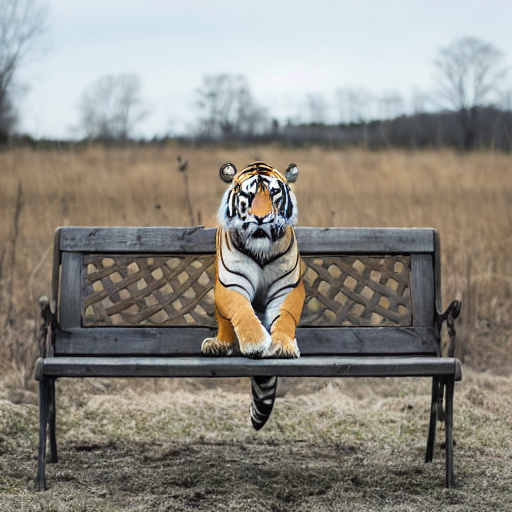

In [10]:
#my code
prompt = (
    "a majestic bengal tiger sitting regally on a wooden bench, "
    "powerful pose, detailed fur texture, sharp focus, natural lighting, "
    "photorealistic, high detail, 8k, national geographic photography"
)

negative_prompt = (
    "blurry, low quality, cartoon, deformed, distorted, extra limbs, "
    "bad anatomy, watermark, text, dull, flat lighting"
)

generator = torch.Generator("cuda").manual_seed(7)  # try a few different seeds

result = pipe_inpaint(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=init_image,
    mask_image=mask_image,
    guidance_scale=9.0,        # push it harder toward the prompt
    num_inference_steps=75,    # more steps = more refined detail
    generator=generator
).images[0]

result

##**Discussion**
    • Does the edited region blend naturally with the rest of the image?
    • What happens if you make the prompt vague vs. very specific?

In [ ]:
#answer here

* Blending quality depends heavily on the inpainting checkpoint and mask edge softness — hard binary masks can leave a visible seam, while a slightly feathered/blurred mask edge blends more naturally into the surrounding pixels.
* A vague prompt ("an animal") gives the model more creative freedom, often producing something generic or inconsistent with the scene's lighting/style. A very specific prompt ("a majestic tiger sitting on a bench, photorealistic, matching lighting") tends to blend better because it constrains the model toward a coherent, well-lit subject — but overly specific prompts can also fight against the existing image content if they contradict it (e.g., describing lighting that doesn't match the source photo).

 # **ControlNet**

 Install and load ControlNet

In [11]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

pipe_cn = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.45GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Create a Canny edge map from a reference image

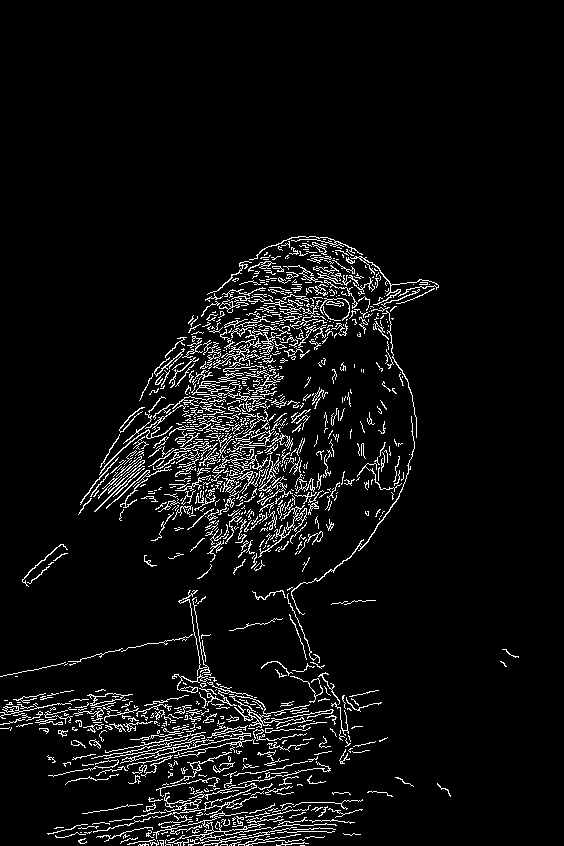

In [13]:
url = "https://huggingface.co/lllyasviel/sd-controlnet-canny/resolve/main/images/bird.png"
ref_image = load_image(url)

#write your code here
image_np = np.array(ref_image)

low_threshold = 100
high_threshold = 200

canny_image = cv2.Canny(image_np, low_threshold, high_threshold)
canny_image = canny_image[:, :, None]
canny_image = np.concatenate([canny_image, canny_image, canny_image], axis=2)
canny_image = Image.fromarray(canny_image)

canny_image

Generate guided by the edge map.

prompt = "a colorful parrot, highly detailed, studio lighting"

  0%|          | 0/30 [00:00<?, ?it/s]

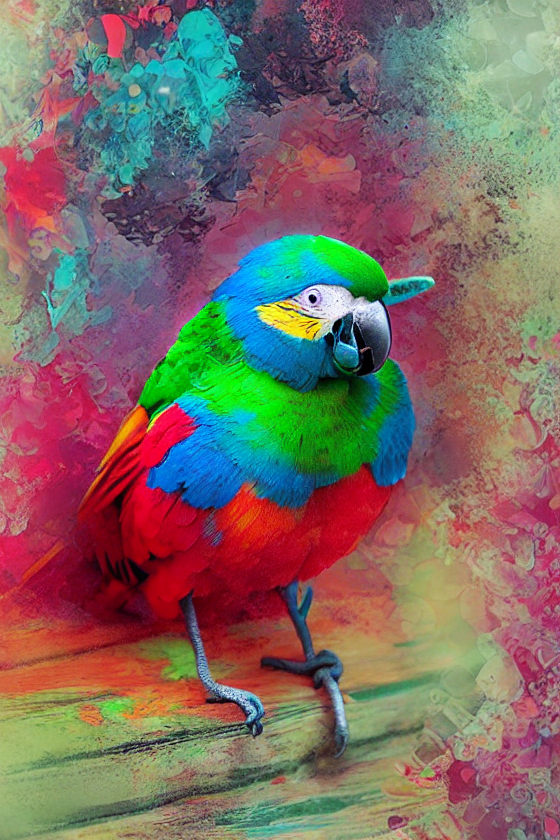

In [20]:
#write your code here
prompt = "a colorful parrot, highly detailed, studio lighting"

generator = torch.Generator("cuda").manual_seed(42)

output = pipe_cn(
    prompt=prompt,
    image=canny_image,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator
).images[0]

output

  0%|          | 0/50 [00:00<?, ?it/s]

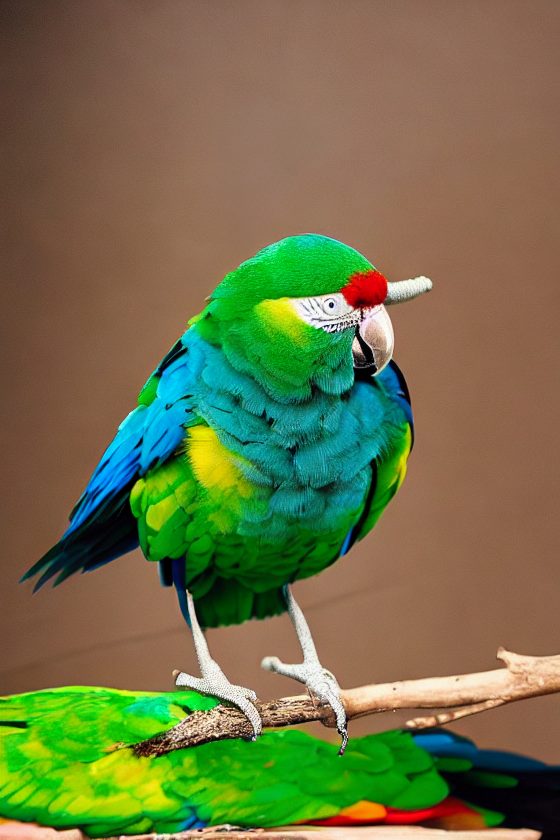

In [15]:
#my code
prompt = (
    "a colorful macaw parrot, photorealistic, highly detailed feathers, "
    "vivid natural colors, perched on a branch, sharp focus, "
    "studio lighting, professional wildlife photography, 8k, national geographic"
)

negative_prompt = (
    "cartoon, illustration, painting, drawing, anime, blurry, low quality, "
    "deformed, extra wings, bad anatomy, watermark, text, low detail"
)

generator = torch.Generator("cuda").manual_seed(7)

output = pipe_cn(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=canny_image,
    num_inference_steps=50,
    guidance_scale=9.0,
    controlnet_conditioning_scale=1.0,   # how strictly to follow the edge map
    generator=generator
).images[0]

output

# **Text-to-Video Exploration**

Load a lightweight text-to-video model

In [16]:
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler

pipe_video = DiffusionPipeline.from_pretrained(
    "damo-vilab/text-to-video-ms-1.7b",
    torch_dtype=torch.float16,
    variant="fp16"
)
pipe_video.scheduler = DPMSolverMultistepScheduler.from_config(pipe_video.scheduler.config)
pipe_video.enable_model_cpu_offload()

model_index.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


Generate a short clip

In [17]:
prompt = "a golden retriever running on a beach at sunset"

video_frames = pipe_video(prompt, num_inference_steps=25).frames[0]
video_path = export_to_video(video_frames)
video_path

  0%|          | 0/25 [00:00<?, ?it/s]

'/tmp/tmp09t8oteb.mp4'

Download the file from the Colab file browser (folder icon on the left) to watch it, or display it inline:

In [18]:
from IPython.display import Video
Video(video_path, embed=True)

Compare against a hosted demo.

Try the same prompt on one public text-to-video demo (e.g. a Hugging Face Space).

Note differences in quality, duration, and consistency.
# **Discussion**
    • How does video generation time compare to a single image?
    • What inconsistencies or artifacts do you notice across frames?

In [ ]:
#write your answer here

1. Video generation takes substantially longer than a single image — the model generates multiple frames (e.g., 16–24) per clip, and each frame effectively involves its own denoising process, so total inference time scales roughly with frame count, often 5–10x+ a single image generation.
2. Common artifacts include flickering/temporal inconsistency (colors or fine details shifting slightly frame to frame), warping or morphing of subjects (e.g., the dog's legs or shape deforming unnaturally between frames), lower overall resolution/sharpness compared to still-image models, and occasional loss of object identity over the clip's duration (the subject drifting away from the prompt's description).

In [21]:
#my code
prompt = "a red sports car driving down a coastal highway at sunset, cinematic"

negative_prompt = "blurry, low quality, distorted, static, watermark, text"

video_frames = pipe_video(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=25,
    num_frames=24,          # more frames = longer clip (default is often 16)
    generator=torch.Generator("cuda").manual_seed(42)
).frames[0]

video_path = export_to_video(video_frames)
video_path

  0%|          | 0/25 [00:00<?, ?it/s]

'/tmp/tmpgrvwgqxt.mp4'

In [22]:
from IPython.display import Video
Video(video_path, embed=True)